<a href="https://colab.research.google.com/github/gerryfrank10/ComputerVision/blob/main/brain_tumor_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
navoneel_brain_mri_images_for_brain_tumor_detection_path = kagglehub.dataset_download('navoneel/brain-mri-images-for-brain-tumor-detection')

print('Data source import complete.')


100%|██████████| 15.1M/15.1M [00:00<00:00, 46.0MB/s]

Extracting files...


Data source import complete.


In [11]:
!ls -lah /root/.cache/kagglehub/datasets/navoneel/brain-mri-images-for-brain-tumor-detection/versions/1/

total 20K
drwxr-xr-x 5 root root 4.0K Sep 19 22:37 .
drwxr-xr-x 3 root root 4.0K Sep 19 22:37 ..
drwxr-xr-x 4 root root 4.0K Sep 19 22:37 brain_tumor_dataset
drwxr-xr-x 2 root root 4.0K Sep 19 22:37 no
drwxr-xr-x 2 root root 4.0K Sep 19 22:37 yes


In [15]:
# put dataset in /kaggle/input/
!cp -r /root/.cache/kagglehub/datasets/navoneel/brain-mri-images-for-brain-tumor-detection/versions/1/brain_tumor_dataset/ /content/

In [16]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/content'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/content/.config/active_config
/content/.config/gce
/content/.config/.last_survey_prompt.yaml
/content/.config/config_sentinel
/content/.config/default_configs.db
/content/.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db
/content/.config/.last_opt_in_prompt.yaml
/content/.config/.last_update_check.json
/content/.config/logs/2025.09.16/13.40.38.414999.log
/content/.config/logs/2025.09.16/13.39.51.530260.log
/content/.config/logs/2025.09.16/13.40.27.693438.log
/content/.config/logs/2025.09.16/13.40.37.615954.log
/content/.config/logs/2025.09.16/13.40.15.959626.log
/content/.config/logs/2025.09.16/13.40.25.424362.log
/content/.config/configurations/config_default
/content/brain_tumor_dataset/yes/Y45.JPG
/content/brain_tumor_dataset/yes/Y117.JPG
/content/brain_tumor_dataset/yes/Y192.JPG
/content/brain_tumor_dataset/yes/Y42.jpg
/content/brain_tumor_dataset/yes/Y255.JPG
/content/brain_tumor_dataset/yes/Y61.jpg
/content/brain_tumor_dataset/yes/Y170.JPG
/content/brain_tum

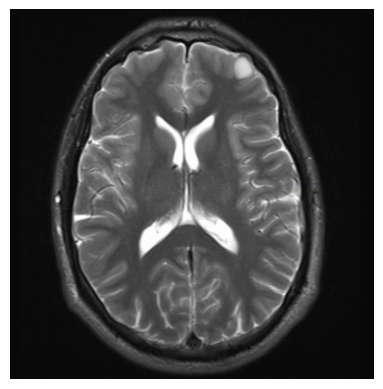

In [18]:
import cv2
import matplotlib.pyplot as plt
img = cv2.imread('/content/brain_tumor_dataset/no/No15.jpg')[:,:,::-1]
plt.axis(False)
plt.imshow(img);

In [19]:
# Number of Images
import os
tumor = os.path.join('/content/brain_tumor_dataset/yes')
no_tumor = os.path.join('/content/brain_tumor_dataset/no')
len(os.listdir(tumor)), len(os.listdir(no_tumor))

(155, 98)

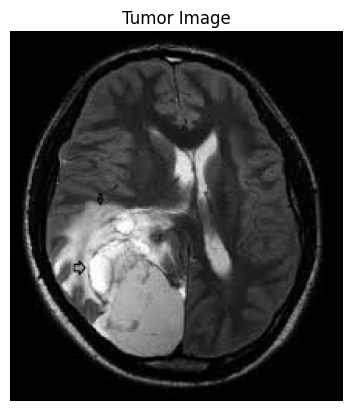

In [21]:
# Loading sample tumor image
import random
import cv2
file = random.choice(os.listdir(tumor))
img = cv2.imread(os.path.join(tumor, file))
plt.title('Tumor Image')
plt.axis(False)
plt.imshow(img);

In [23]:
import torch
from torchvision import transforms, datasets
from torchvision.models import resnet50
from torch.utils.data import DataLoader

In [24]:
path = '/content/brain_tumor_dataset'
# Create a transform
transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5,0.5,0.5],
                        std=[0.5,0.5,0.5])
])
# datasets
dataset = datasets.ImageFolder(root=path, transform=transform)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])
len(train_dataset), len(test_dataset)

(202, 51)

In [25]:
# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True)

In [26]:
device = ('gpu' if torch.cuda.is_available() else 'cpu')
model = resnet50(pretrained=True)
model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 110MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [31]:
# We are predicting 2 classes only so
from torch import nn

# Freeze some model layers
for param in model.parameters():
    param.requires_grad = False

model.fc = torch.nn.Linear(in_features=model.fc.in_features, out_features=2)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [35]:
def train(model, train_loader, optimizer, criterion):
    model.train()
    train_loss = 0.0

    for image, label in train_loader:
        image, label = image.to(device), label.to(device)
        optimizer.zero_grad()
        output = model(image)
        loss = criterion(output, label)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * image.size(0)

    return train_loss / len(train_loader.dataset)

In [38]:
def evaluate(model, test_loader, criterion):
    model.eval()
    test_loss = 0.0
    correct = 0
    with torch.no_grad():
        for image, label in test_loader:
            image, label = image.to(device), label.to(device)
            output = model(image)
            loss = criterion(output, label)
            test_loss += loss.item() * image.size(0)
            _, pred = torch.max(output, 1)
            correct += torch.sum(pred == label.data)
    print(f'Test Accuracy : {100* correct/len(test_loader.dataset)}')
    return test_loss / len(test_loader.dataset)

In [39]:
epochs = 3
for epoch in range(epochs):
    train_loss = train(model, train_loader, optimizer, criterion)
    test_loss = evaluate(model, test_loader, criterion)
    print(f'Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}')

Test Accuracy : 90.19607543945312
Epoch 1/3, Train Loss: 0.5063, Test Loss: 0.3961
Test Accuracy : 92.1568603515625
Epoch 2/3, Train Loss: 0.4423, Test Loss: 0.3234
Test Accuracy : 94.11764526367188
Epoch 3/3, Train Loss: 0.3286, Test Loss: 0.2780
